Your task:
Make the graph on the right! You need to implement an Automatic Higher or Lower
Game.
Set the bounds to between 1 to 20. The Graph has to keep guessing (max number of
guesses is 7) where if the guess is correct, then it stops, but if not we keep looping until
we hit the max limit of 7.
Each time a number is guessed, the hint node should say higher or lower and the graph
should account for this information and guess the next guess accordingly.
Input: {"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1,
"upper_bound": 20}
Hint: It will need to adjust its bounds after every guess based on the hint provided by the
hint node.

In [94]:
from langgraph.graph import StateGraph, END
from typing import TypedDict,List
import random

In [108]:
###state

class Agentstate(TypedDict):
    
    user: str
    result: str
    guesses: List[int]
    lower_b: int
    upper_b: int
    attempts: int
    target: int
    

In [121]:
## defining nodes

def setup_node(state:Agentstate)->Agentstate:

    """
    this node sets up all the initial values for the game

    """
    

    state['result'] = f'{state["user"]}, welcome to the system! '

    state['lower_b'] = 1
    state['upper_b'] = 20

    state['attempts']= 0

    state['guesses'] = []

    target = random.randint(state['lower_b'],state['upper_b'])
    state['target'] = target

    return state


def guess_node(state:Agentstate)->Agentstate:

    """ This node guesses a number between upper_b and loweer_b"""

    #print(state)

    guess = random.randint(state['lower_b'],state['upper_b'])

    state['guesses'].append(guess)

    state['attempts']+=1

    return state


def hint_node(state:Agentstate)->Agentstate:

    last_guess = state['guesses'][-1]

    if last_guess<state['target']:

            state['lower_b'] = last_guess

    if last_guess>state['target']:

            state['upper_b'] = last_guess

    return state
            


def hint_node_decision(state:Agentstate)->str:

    """this node gives hint for the next guess or ends the game if guess is correct"""

    if state['attempts']<=7:

        last_guess = state['guesses'][-1]

        if last_guess==state['target']:
            
            return 'end'

        else:
            return 'continue'

    else:
        
        return 'end'
            
    

In [122]:

graph = StateGraph(Agentstate)

In [123]:
graph.add_node('setter',setup_node)
graph.add_node('guesser',guess_node)

graph.add_node('hinter',hint_node)

graph.add_edge('setter','guesser')

graph.add_edge('guesser','hinter')

graph.set_entry_point('setter')

graph.add_conditional_edges('hinter',hint_node_decision,{'end':END,'continue':'guesser'})

In [124]:
app = graph.compile()

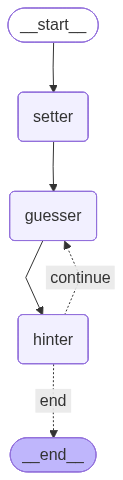

In [125]:
app

In [126]:
app.invoke({'user':'Subh'})

{'user': 'Subh',
 'result': 'Subh, welcome to the system! ',
 'guesses': [14, 4, 4, 8, 12, 12, 13],
 'lower_b': 12,
 'upper_b': 14,
 'attempts': 7,
 'target': 13}